In [5]:
import itertools
import numpy as np
import scipy as sp
from matplotlib import pyplot as plt
import pandas as pd
import seaborn as sns
import pickle


import STX3KO_analyses as stx
from STX3KO_analyses import utilities_ES as u

ko_mice = stx.ymaze_sess_deets.ko_mice
ctrl_mice = stx.ymaze_sess_deets.ctrl_mice
sparse_mice = stx.ymaze_sess_deets.sparse_mice

plt.rcParams['pdf.fonttype']=42
plt.rcParams['font.family'] ='sans-serif'
plt.rcParams['font.serif'] = 'Arial'


%matplotlib inline

%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [6]:
import pickle 
with open('/home/mplitt/shuffle_pkls/sparse_place_field_spatial_shuffle_spks_th.pkl','rb') as file:
    shuff_results = pickle.load(file)

In [7]:
df = {'chan': [], 'mouse': [], 'day': [], 'nov': [], 'n_fields': []}
for mouse in sparse_mice:
    for day in range(6):
        if (mouse == 'SparseKO_09') and (day==2):
            continue

        for nov in ('fam','nov'):
            for chan in ('channel_0', 'channel_1'):
                # n_fields = shuff_results[mouse][chan][day][nov]['num_fields']

                rising_edges = shuff_results[mouse][chan][day][nov]['rising_edges']
                falling_edges = shuff_results[mouse][chan][day][nov]['falling_edges']

                width = falling_edges[:,1]-rising_edges[:,1]
                mask = (width>1) * (width<25)

                n_fields = np.bincount(rising_edges[mask,0])
                

                # widths = shuff_resu
        
                n_fields = n_fields[n_fields>0]

                for n in n_fields:
                    df['mouse'].append(mouse)
                    df['day'].append(day)
                    df['nov'].append(nov)
                    df['chan'].append(chan)
                    df['n_fields'].append(n)

df = pd.DataFrame.from_dict(df)
        

(0.0, 1.1)

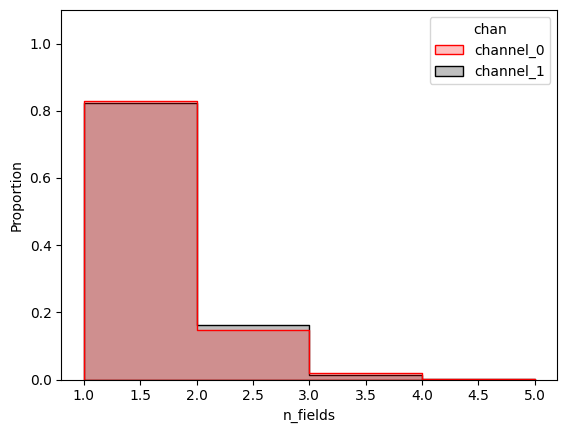

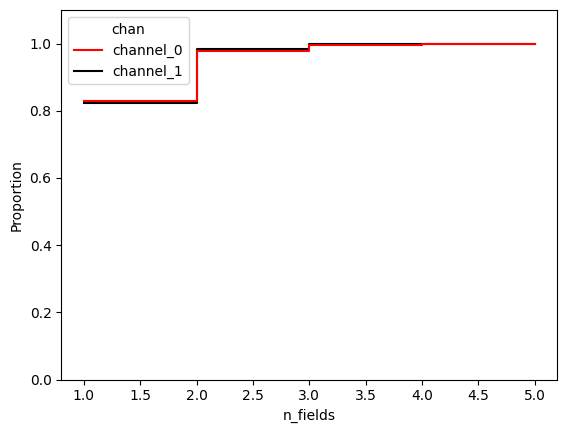

In [8]:
fig,ax = plt.subplots()
sns.histplot(data=df, x='n_fields', hue='chan', cumulative=False, hue_order=('channel_0', 'channel_1'), palette=['red', 'black'],
            binwidth=1, fill=True, element = 'step', stat='proportion', common_norm=False, ax=ax)
ax.set_ylim([0,1.1])

fig,ax = plt.subplots()
sns.histplot(data=df, x='n_fields', hue='chan', cumulative=True, hue_order=('channel_0', 'channel_1'), palette=['red', 'black'],
            binwidth=1, fill=False, element = 'step', stat='proportion', common_norm=False, ax=ax)
ax.set_ylim([0,1.1])



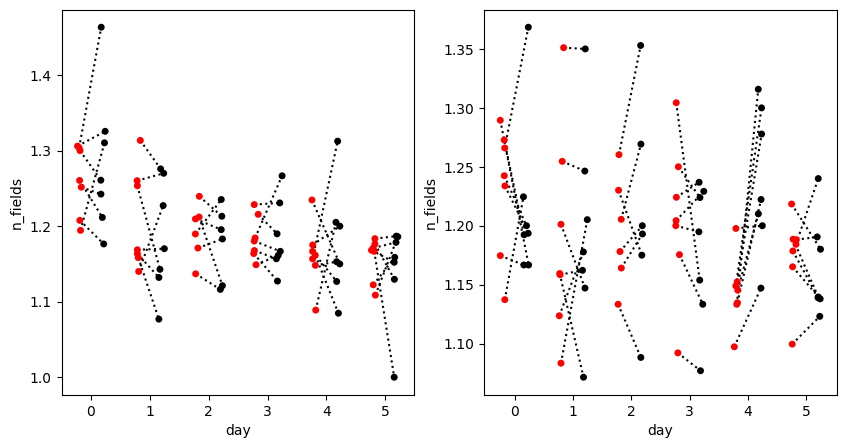

In [9]:
df_mu = df.groupby(['mouse','day','chan','nov'])['n_fields'].mean().reset_index()
df_mu.head()
fig,ax = plt.subplots(1,2, figsize=[10,5])
for i, nov in enumerate(('fam','nov')):
    ax[i] = sns.stripplot(data=df_mu.loc[df_mu['nov']==nov,:],
                x='day',
                y='n_fields',
                hue='chan', 
                hue_order=('channel_0', 'channel_1'), 
                palette=['red', 'black'],
                dodge=True,
                ax=ax[i],
                legend=False)


    for d in range(0,12,2):
        for (x0, y0), (x1, y1) in zip(ax[i].collections[d].get_offsets(), ax[i].collections[d+1].get_offsets()):
            ax[i].plot([x0, x1], [y0, y1], color='black', ls=':', zorder=0)



In [23]:
true_rank_sum, p = sp.stats.mannwhitneyu(df.loc[df['chan']=='channel_0','n_fields'],df.loc[df['chan']=='channel_1','n_fields'])
# p = (rank_sum_shuffle>true_rank_sum).sum().astype(float)/len(rank_sum_shuffle)
print(f'p-value = {p}')

p-value = 0.42136440493147953


In [24]:
df = {'chan': [], 'mouse': [], 'day': [], 'nov': [], 'width': []}
for mouse in sparse_mice:
    for day in range(6):
        
        if (mouse == 'SparseKO_09') and (day==2):
            continue

        for nov in ('fam','nov'):
            for chan in ('channel_0', 'channel_1'):
                widths = shuff_results[mouse][chan][day][nov]['field_widths']
                widths = widths[(widths>1) * (widths<25)]

                for w in widths:
                   
                    df['mouse'].append(mouse)
                    df['day'].append(day)
                    df['nov'].append(nov)
                    df['chan'].append(chan)
                    df['width'].append(w)

                    # df['speed'].append(avg_speed[ledge[0]:ledge[0]+redge+1][0]*10*sess.scan_info['frame_rate'])
#                             # print(avg_speed[ledge[0]:ledge[0]+redge+1])
df = pd.DataFrame.from_dict(df)

<Axes: xlabel='width', ylabel='Proportion'>

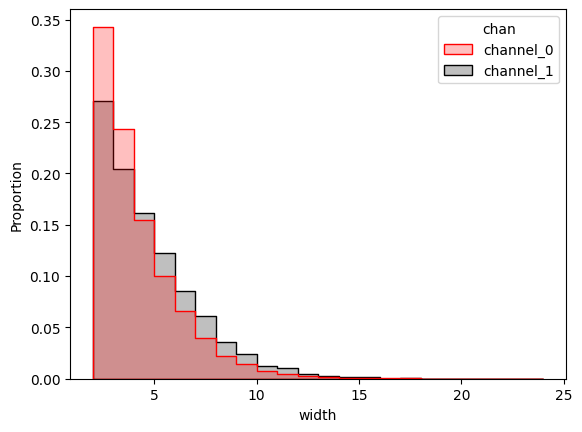

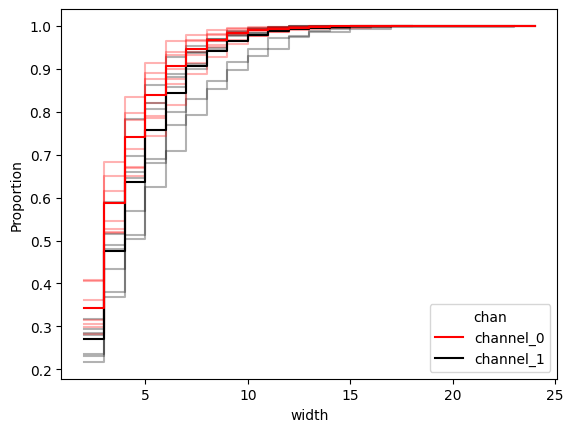

In [35]:
fig,ax = plt.subplots()
sns.histplot(data=df, x='width', hue='chan', cumulative=False, hue_order=('channel_0', 'channel_1'), palette=['red', 'black'],
            binwidth=1, fill=True, element = 'step', stat='proportion', common_norm=False, ax=ax)
# ax.set_ylim([0,1.1])

fig, ax = plt.subplots()
for mouse in sparse_mice:
    tmp_df = df.loc[df['mouse']==mouse,:]
    sns.histplot(data=tmp_df,
                 x='width', 
                 hue='chan', 
                 cumulative=True, 
                 hue_order=('channel_0', 'channel_1'), 
                 palette=['red', 'black'],
                 binwidth=1,
                 fill = False, 
                 element='step',
                 stat = 'proportion',
                 common_norm=False,
                 ax=ax,
                 alpha=.3)
    
sns.histplot(data=df, x='width', hue='chan', cumulative=True, hue_order=('channel_0', 'channel_1'), palette=['red', 'black'],
            binwidth=1, fill=False, element = 'step', stat='proportion', common_norm=False, ax=ax)

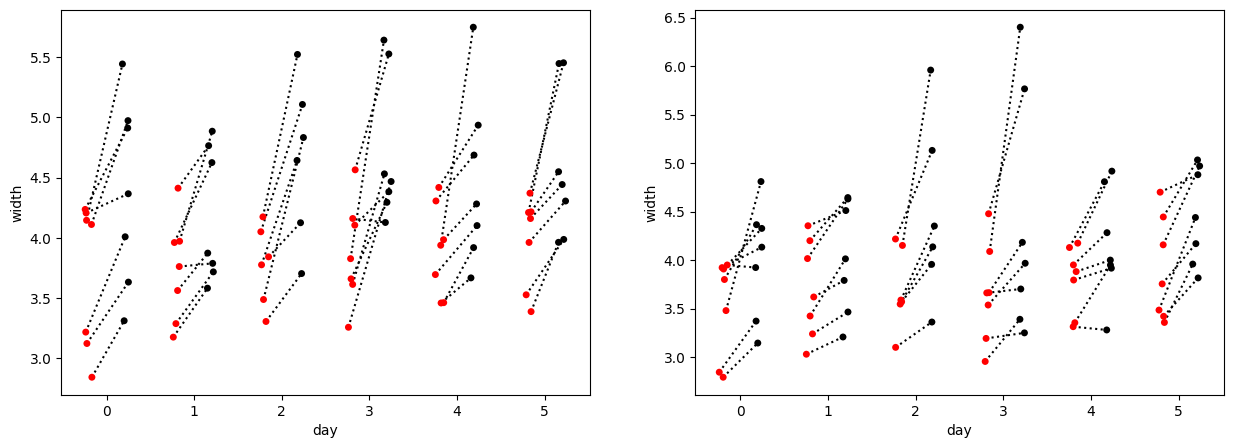

In [37]:
df_mu = df.groupby(['mouse','day','chan','nov'])['width'].mean().reset_index()
df_mu.head()
fig,ax = plt.subplots(1,2, figsize=[15,5])
for i, nov in enumerate(('fam','nov')):
    ax[i] = sns.stripplot(data=df_mu.loc[df_mu['nov']==nov,:],
                x='day',
                y='width',
                hue='chan', 
                hue_order=('channel_0', 'channel_1'), 
                palette=['red', 'black'],
                dodge=.2,
                ax=ax[i],
                legend=False)


    for d in range(0,12,2):
        for (x0, y0), (x1, y1) in zip(ax[i].collections[d].get_offsets(), ax[i].collections[d+1].get_offsets()):
            ax[i].plot([x0, x1], [y0, y1], color='black', ls=':', zorder=0)

In [27]:
true_rank_sum, p = sp.stats.ranksums(df.loc[df['chan']=='channel_0','width'],df.loc[df['chan']=='channel_1','width'])
# p = (rank_sum_shuffle<true_rank_sum).sum().astype(float)/len(rank_sum_shuffle)
print(f'p-value = {p}')

p-value = 1.2689557402059924e-43
